In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")
print(f"PyTorch version: {torch.__version__}")

NUM_WORKERS = 2


Using device: cuda
PyTorch version: 2.11.0+cu128


In [2]:
def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, is_inception=False):
    """Train CNN and return history"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, train_accs, test_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            if is_inception:
                outputs, aux_outputs = model(images)
                loss1 = criterion(outputs, labels)
                loss2 = criterion(aux_outputs, labels)
                loss = loss1 + 0.4 * loss2
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            if (batch_idx + 1) % 50 == 0:
                batch_acc = 100. * correct / total
                print(f"  Batch [{batch_idx+1}/{len(train_loader)}] Loss: {loss.item():.4f} Acc: {batch_acc:.2f}%")

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_acc = 100. * correct / total
        test_accs.append(test_acc)

        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"  Test: Acc={test_acc:.2f}%")
        print("-"*60)

    return train_losses, train_accs, test_accs


In [3]:
from torchvision.datasets import OxfordIIITPet

transform_pets_train = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_pets_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

pets_train = OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform_pets_train)
pets_test = OxfordIIITPet(root='./data', split='test', download=True, transform=transform_pets_test)

pets_train_loader = DataLoader(pets_train, batch_size=32, shuffle=True, num_workers=NUM_WORKERS)
pets_test_loader = DataLoader(pets_test, batch_size=32, shuffle=False, num_workers=NUM_WORKERS)

print(f"Training samples: {len(pets_train)}")
print(f"Test samples: {len(pets_test)}")
print(f"Number of breeds: 37 (25 dogs + 12 cats)")
print(f"Image size: 224x224")


100%|██████████| 792M/792M [00:36<00:00, 21.8MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.5MB/s]


Training samples: 3680
Test samples: 3669
Number of breeds: 37 (25 dogs + 12 cats)
Image size: 224x224


In [4]:
class VanillaCNN(nn.Module):
    def __init__(self, num_classes=37):
        super(VanillaCNN, self).__init__()

        # Block 1: 3 -> 32 channels
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)  # 224 -> 112
        )

        # Block 2: 32 -> 64 channels
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)  # 112 -> 56
        )

        # Block 3: 64 -> 128 channels
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)  # 56 -> 28
        )

        # Block 4: 128 -> 256 channels
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)  # 28 -> 14
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),   # بنستخدم Dropout هنا عشان overfitting متوقع
                               # يكون أعلى (مفيش pretrained features تساعد)
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x



In [5]:
print("Building Vanilla CNN from scratch (no pretrained weights)...")

vanilla_model = VanillaCNN(num_classes=37)
vanilla_model = vanilla_model.to(device)

print("\nVanilla CNN built!")
print("Architecture: 4 Conv blocks (32->64->128->256 channels) + 2 FC layers")

total_params = sum(p.numel() for p in vanilla_model.parameters())
trainable_params = sum(p.numel() for p in vanilla_model.parameters() if p.requires_grad)

print(f"\nVanilla CNN (From Scratch):")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} (ALL layers - no freezing)")
print(f"\nReady to train on Oxford Pets!")

Building Vanilla CNN from scratch (no pretrained weights)...

Vanilla CNN built!
Architecture: 4 Conv blocks (32->64->128->256 channels) + 2 FC layers

Vanilla CNN (From Scratch):
Total parameters: 26,098,981
Trainable parameters: 26,098,981 (ALL layers - no freezing)

Ready to train on Oxford Pets!


In [6]:
print("Training Vanilla CNN from Scratch on Oxford Pets (20 epochs)...")
print("(All layers trainable - training from random initialization)")

vanilla_train_losses, vanilla_train_accs, vanilla_test_accs = train_model(
    vanilla_model, pets_train_loader, pets_test_loader, epochs=20, lr=0.001
)

print(f"\nTraining complete!")
print(f"Final Train Accuracy: {vanilla_train_accs[-1]:.2f}%")
print(f"Final Test Accuracy: {vanilla_test_accs[-1]:.2f}%")
print(f"\nNote: من الصفر بدون pretrained weights - النتيجة غالبًا هتبقى")
print(f"أقل بكتير من الـ Transfer Learning models. ده متوقع ومطلوب")
print(f"يتوضح في المقارنة (بيوضح قد إيه الـ pretrained features مفيدة).")


Training Vanilla CNN from Scratch on Oxford Pets (20 epochs)...
(All layers trainable - training from random initialization)
  Batch [50/115] Loss: 3.6216 Acc: 3.00%
  Batch [100/115] Loss: 3.6410 Acc: 2.62%

Epoch [1/20]
  Train: Loss=5.3653, Acc=2.50%
  Test: Acc=2.73%
------------------------------------------------------------
  Batch [50/115] Loss: 3.6128 Acc: 3.62%
  Batch [100/115] Loss: 3.6156 Acc: 2.75%

Epoch [2/20]
  Train: Loss=3.6116, Acc=2.69%
  Test: Acc=2.73%
------------------------------------------------------------
  Batch [50/115] Loss: 3.6079 Acc: 2.25%
  Batch [100/115] Loss: 3.6097 Acc: 2.38%

Epoch [3/20]
  Train: Loss=3.6118, Acc=2.45%
  Test: Acc=2.67%
------------------------------------------------------------
  Batch [50/115] Loss: 3.6146 Acc: 2.75%
  Batch [100/115] Loss: 3.6165 Acc: 2.59%

Epoch [4/20]
  Train: Loss=3.6118, Acc=2.53%
  Test: Acc=2.73%
------------------------------------------------------------
  Batch [50/115] Loss: 3.6117 Acc: 2.94%
  

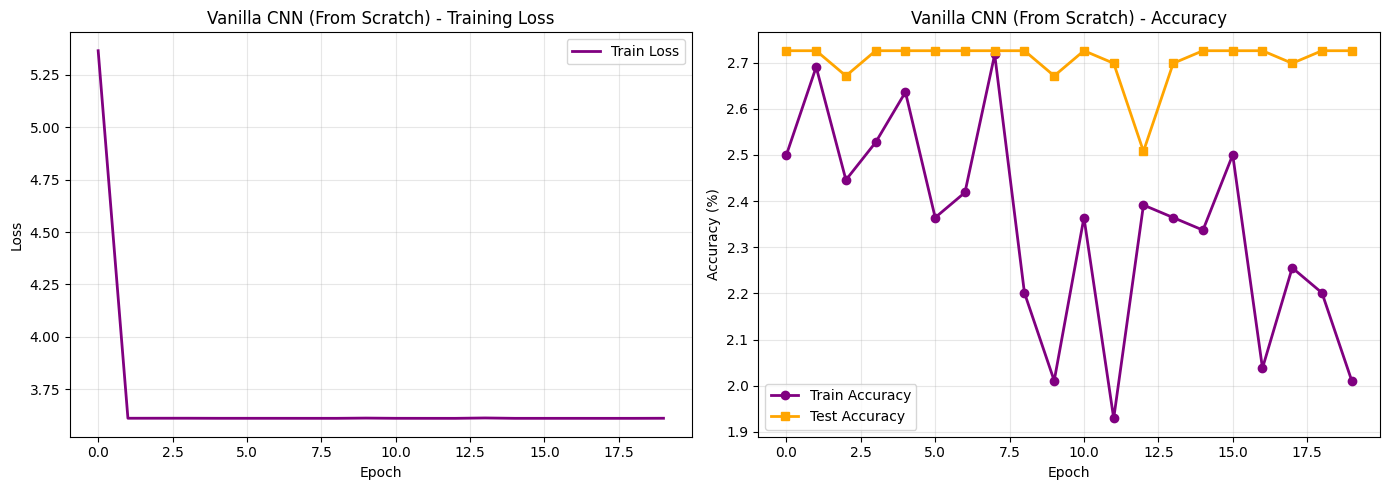

VANILLA CNN RESULTS
Vanilla CNN (From Scratch): 2.73%

Task: Classify 37 pet breeds
Parameters trained: 26,098,981 (ALL - trained from scratch)


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(vanilla_train_losses, 'purple', linewidth=2, label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Vanilla CNN (From Scratch) - Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(vanilla_train_accs, 'purple', linewidth=2, label='Train Accuracy', marker='o')
ax2.plot(vanilla_test_accs, 'orange', linewidth=2, label='Test Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Vanilla CNN (From Scratch) - Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("VANILLA CNN RESULTS")
print(f"Vanilla CNN (From Scratch): {vanilla_test_accs[-1]:.2f}%")
print(f"\nTask: Classify 37 pet breeds")
print(f"Parameters trained: {trainable_params:,} (ALL - trained from scratch)")


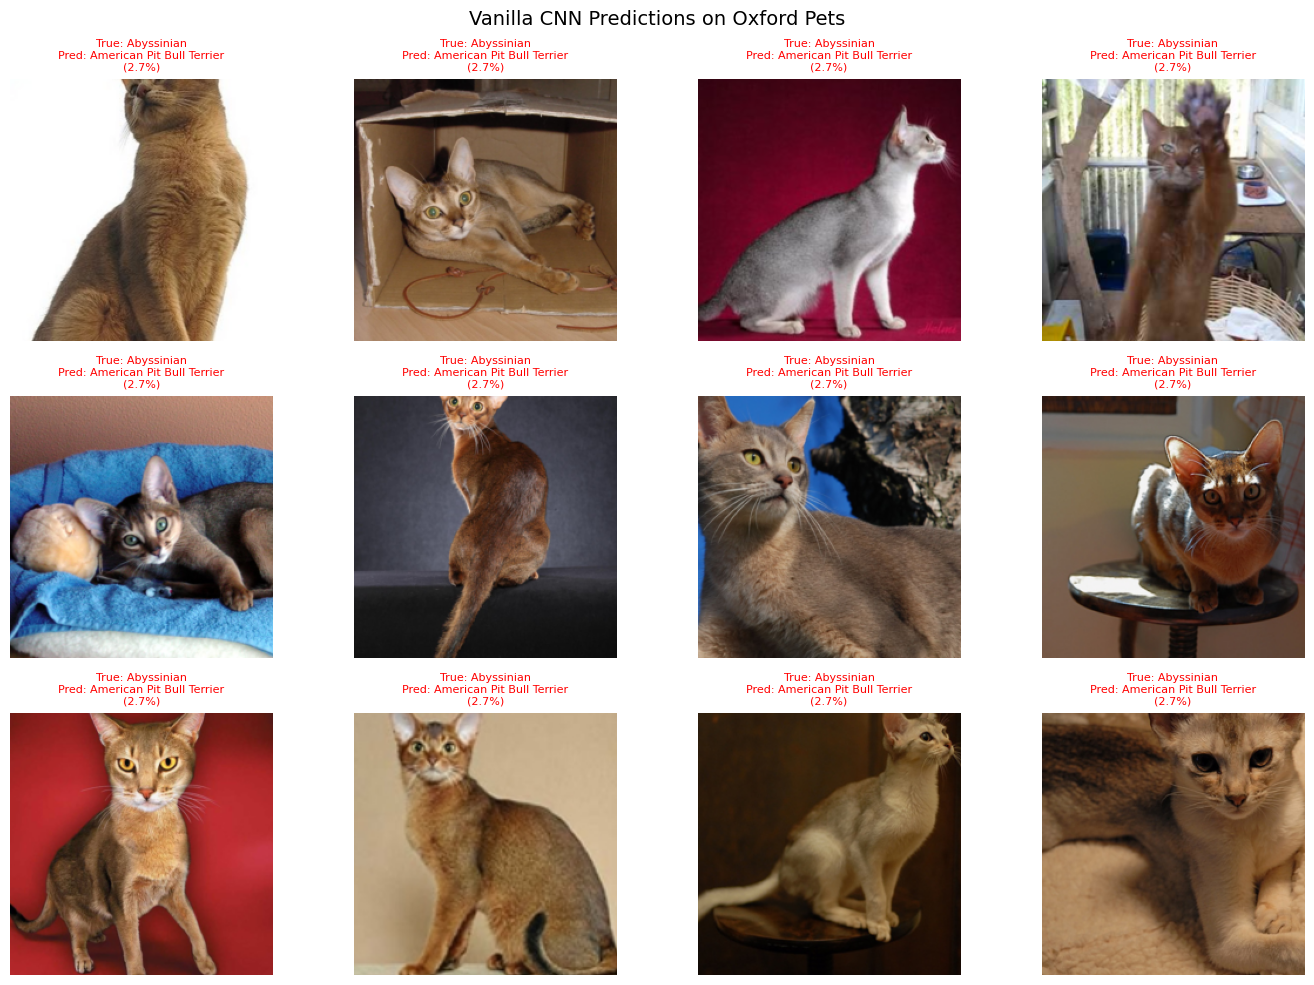


Batch Accuracy: 0.0%
Correct: 0/32


In [8]:
vanilla_model.eval()

dataiter = iter(pets_test_loader)
next(dataiter)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = vanilla_model(images)
    _, predicted = outputs.max(1)
    probabilities = torch.softmax(outputs, dim=1)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
images_denorm = images * std + mean

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("Vanilla CNN Predictions on Oxford Pets", fontsize=14, y=0.98)

for idx, ax in enumerate(axes.flat):
    img = images_denorm[idx].cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    true_label = pets_test.classes[labels[idx]].replace('_', ' ').title()
    pred_label = pets_test.classes[predicted[idx]].replace('_', ' ').title()
    confidence = probabilities[idx][predicted[idx]].item() * 100

    ax.imshow(img)
    color = 'lime' if predicted[idx] == labels[idx] else 'red'
    title = f"True: {true_label}\nPred: {pred_label}\n({confidence:.1f}%)"
    ax.set_title(title, fontsize=8, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

batch_acc = (predicted == labels).sum().item() / len(labels) * 100
print(f"\nBatch Accuracy: {batch_acc:.1f}%")
print(f"Correct: {(predicted == labels).sum().item()}/{len(labels)}")


In [9]:

import json

results = {
    "model": "Vanilla CNN",
    "test_acc": vanilla_test_accs[-1],
    "train_acc": vanilla_train_accs[-1],
    "total_params": total_params,
    "trainable_params": trainable_params,
}

with open("vanilla_cnn_results.json", "w") as f:
    json.dump(results, f)

print("Results saved to vanilla_cnn_results.json")

Results saved to vanilla_cnn_results.json


In [12]:
import json
import pandas as pd

all_results = []

result_files = {
    "ResNet50": "resnet50_results.json",
    "VGG16": "vgg16_results.json",
    "InceptionV3": "inceptionv3_results.json",
    "Vanilla CNN": "vanilla_cnn_results.json",
}

for model_name, filepath in result_files.items():
    try:
        with open(filepath, "r") as f:
            data = json.load(f)
            all_results.append(data)
    except FileNotFoundError:
        print(f"⚠️  Warning: {filepath} not found - skipping {model_name}")
        print(f"    (Make sure you ran the {model_name} notebook and saved its results)")

comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values("test_acc", ascending=False).reset_index(drop=True)

print("FINAL COMPARISON - All Models")
print(comparison_df.to_string(index=False))


⚠️  Warning: resnet50_results.json not found - skipping ResNet50
    (Make sure you ran the ResNet50 notebook and saved its results)
⚠️  Warning: vgg16_results.json not found - skipping VGG16
    (Make sure you ran the VGG16 notebook and saved its results)
⚠️  Warning: inceptionv3_results.json not found - skipping InceptionV3
    (Make sure you ran the InceptionV3 notebook and saved its results)
FINAL COMPARISON - All Models
      model  test_acc  train_acc  total_params  trainable_params
Vanilla CNN  2.725538    2.01087      26098981          26098981


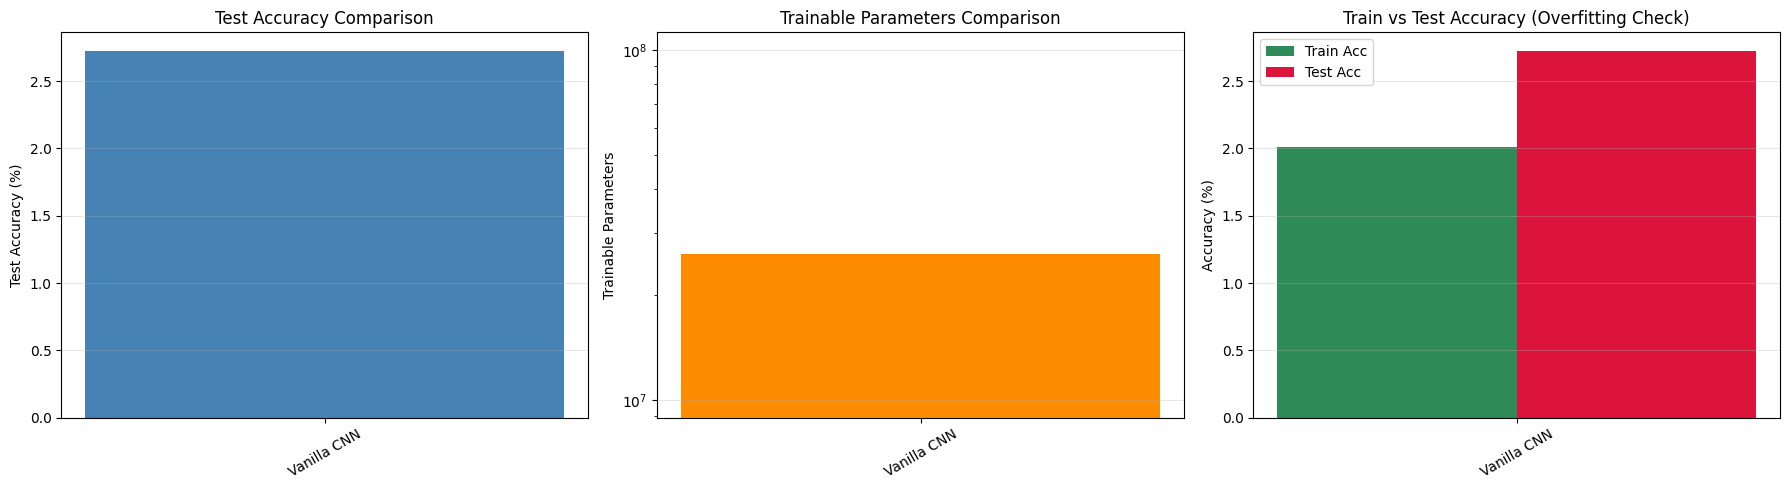


Notes for Report:
- Is there a large gap between Train and Test accuracy in Vanilla CNN? That indicates overfitting,
  which is expected as it learns from scratch on a relatively small dataset.
- Pre-trained models (especially with far fewer trainable parameters)
  are expected to achieve higher accuracy with less training time—this is the core
  argument for Transfer Learning.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Test Accuracy comparison
axes[0].bar(comparison_df["model"], comparison_df["test_acc"], color='steelblue')
axes[0].set_ylabel("Test Accuracy (%)")
axes[0].set_title("Test Accuracy Comparison")
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Trainable Parameters comparison (log scale لأن الفرق كبير جدًا)
axes[1].bar(comparison_df["model"], comparison_df["trainable_params"], color='darkorange')
axes[1].set_ylabel("Trainable Parameters")
axes[1].set_title("Trainable Parameters Comparison")
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Train vs Test Accuracy (عشان نلاحظ overfitting)
x = np.arange(len(comparison_df))
width = 0.35
axes[2].bar(x - width/2, comparison_df["train_acc"], width, label='Train Acc', color='seagreen')
axes[2].bar(x + width/2, comparison_df["test_acc"], width, label='Test Acc', color='crimson')
axes[2].set_xticks(x)
axes[2].set_xticklabels(comparison_df["model"], rotation=30)
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Train vs Test Accuracy (Overfitting Check)")
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNotes for Report:")
print("- Is there a large gap between Train and Test accuracy in Vanilla CNN? That indicates overfitting,")
print("  which is expected as it learns from scratch on a relatively small dataset.")
print("- Pre-trained models (especially with far fewer trainable parameters)")
print("  are expected to achieve higher accuracy with less training time—this is the core")
print("  argument for Transfer Learning.")